 Import the required libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("netflix_titles.csv")

In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.shape

(8807, 12)

In [10]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [15]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [16]:
df.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [19]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

Handling the missing values

In [21]:
df['director'] = df['director'].fillna('unknown')
df['director']

0       Kirsten Johnson
1               unknown
2       Julien Leclercq
3               unknown
4               unknown
             ...       
8802      David Fincher
8803            unknown
8804    Ruben Fleischer
8805       Peter Hewitt
8806        Mozez Singh
Name: director, Length: 8807, dtype: object

In [22]:
df['country'] = df['country'].fillna('unknown')
df['country']

0       United States
1        South Africa
2             unknown
3             unknown
4               India
            ...      
8802    United States
8803          unknown
8804    United States
8805    United States
8806            India
Name: country, Length: 8807, dtype: object

In [23]:
df['cast']=df['cast'].fillna('Unknown')
df['cast']

0                                                 Unknown
1       Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2       Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                                 Unknown
4       Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
                              ...                        
8802    Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...
8803                                              Unknown
8804    Jesse Eisenberg, Woody Harrelson, Emma Stone, ...
8805    Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...
8806    Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...
Name: cast, Length: 8807, dtype: object

In [24]:
df['date_added']=df['date_added'].fillna('Unknown')
df['date_added']

0       September 25, 2021
1       September 24, 2021
2       September 24, 2021
3       September 24, 2021
4       September 24, 2021
               ...        
8802     November 20, 2019
8803          July 1, 2019
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
Name: date_added, Length: 8807, dtype: object

In [27]:
df['rating']=df['rating'].fillna('not rated')
df['rating']

0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8802        R
8803    TV-Y7
8804        R
8805       PG
8806    TV-14
Name: rating, Length: 8807, dtype: object

In [29]:
df['duration']=df['duration'].fillna(df['duration'].mode()[0])
df['duration']

0          90 min
1       2 Seasons
2        1 Season
3        1 Season
4       2 Seasons
          ...    
8802      158 min
8803    2 Seasons
8804       88 min
8805       88 min
8806      111 min
Name: duration, Length: 8807, dtype: object

In [30]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

Convert date_added to datetime

In [34]:
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [37]:
df['released_month'] = df['date_added'].dt.month_name()

In [39]:
df['released_day'] = df['date_added'].dt.day

In [49]:
df['released_year'] = df['date_added'].dt.year

In [50]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,released_month,released_day,released_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,25.0,2021.0
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,24.0,2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,24.0,2021.0
3,s4,TV Show,Jailbirds New Orleans,unknown,Unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,24.0,2021.0
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,24.0,2021.0


In [44]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'released_month', 'released_day', 'released_year'],
      dtype='object')

In [45]:
plt.style.use("ggplot")

UNIVARIATE ANALYSIS

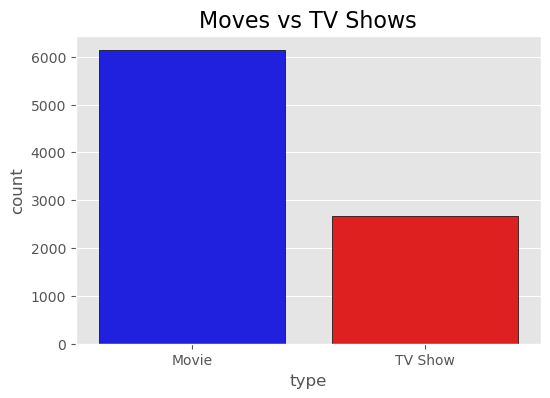

In [65]:
plt.figure(figsize=(6,4))
sns.countplot(x = 'type',data=df,palette=['blue','red'],edgecolor='black')
plt.title("Moves vs TV Shows",fontsize=16)
plt.show()

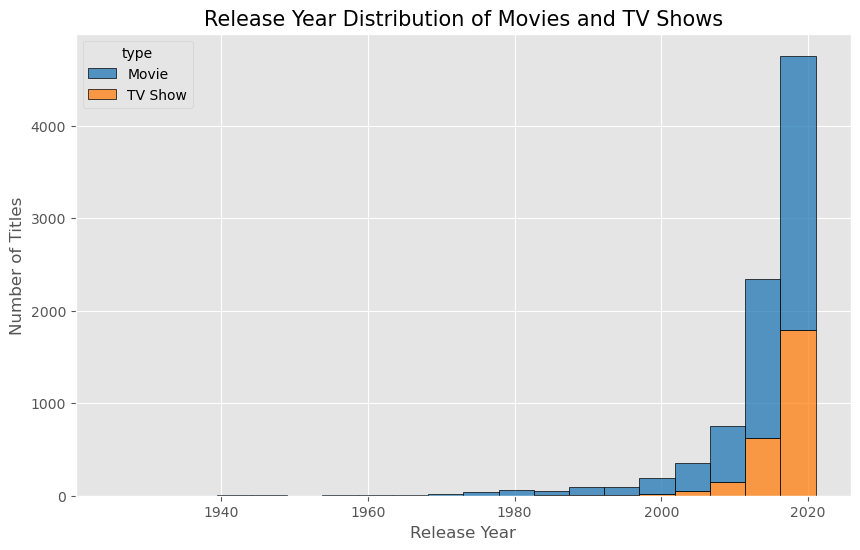

In [59]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='release_year',
    hue='type',
    bins = 20,
    multiple='stack',
    palette=['#1f77b4', '#ff7f0e'],
    edgecolor='black')
plt.title("Release Year Distribution of Movies and TV Shows", fontsize=15)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

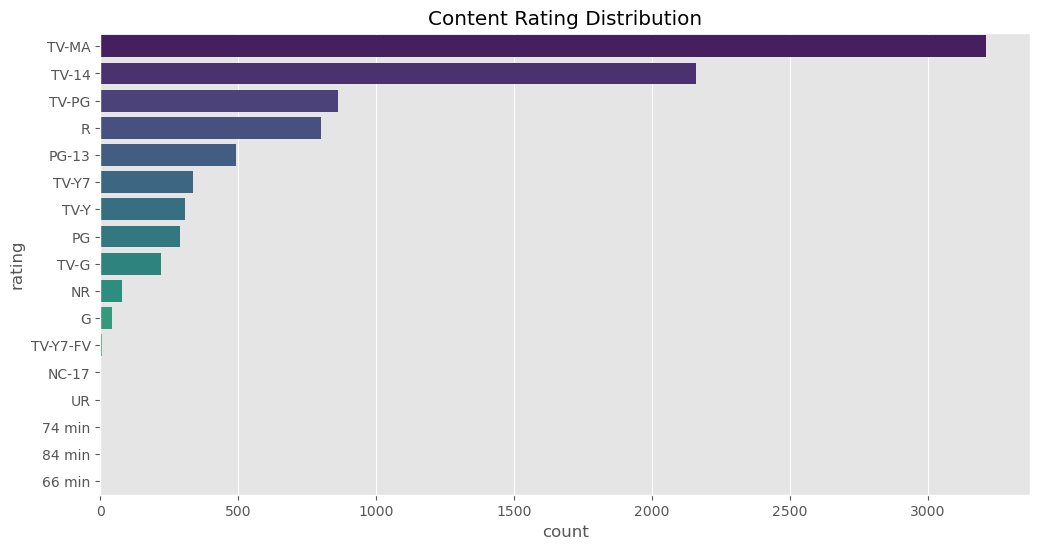

In [69]:
plt.figure(figsize=(12,6))
sns.countplot(
    y=df['rating'],
    order=df['rating'].value_counts().index,
    palette="viridis")
plt.title("Content Rating Distribution")
plt.show()

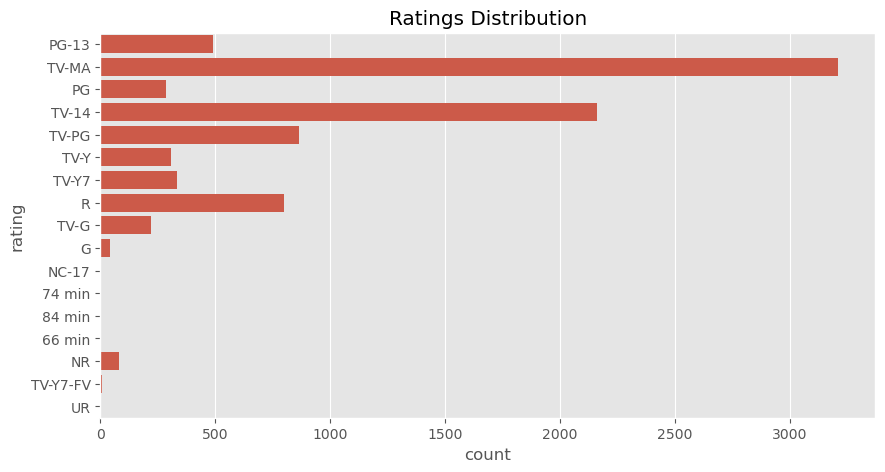

In [70]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating', data=df)
plt.title("Ratings Distribution")
plt.show()

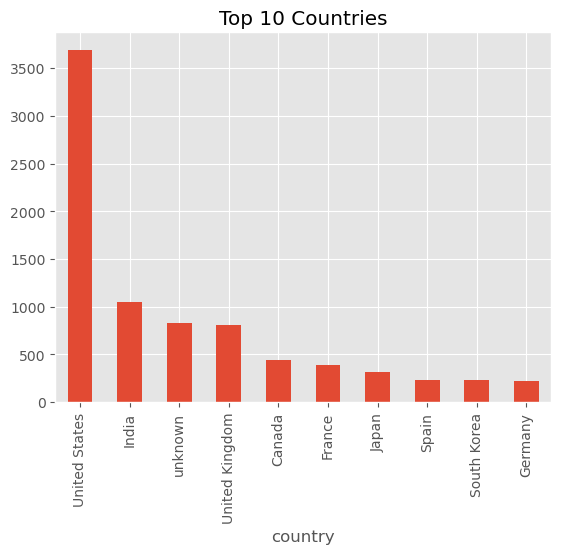

In [85]:
country = df['country'].dropna().str.split(', ').explode()
country.value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

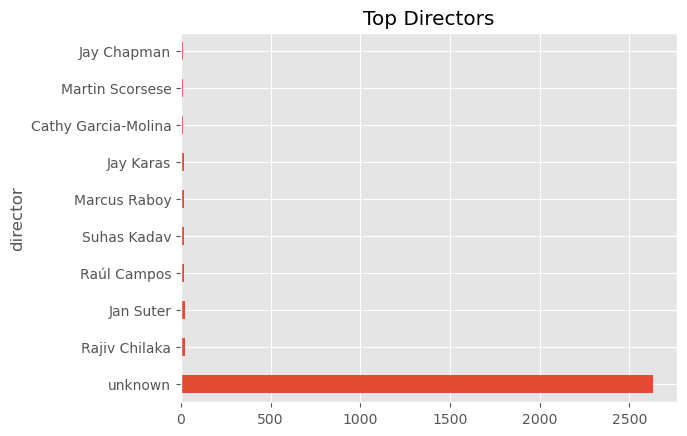

In [86]:
director = df['director'].dropna().str.split(', ').explode()
director.value_counts().head(10).plot(kind='barh')
plt.title("Top Directors")
plt.show()


BIVARIATE ANALYSIS

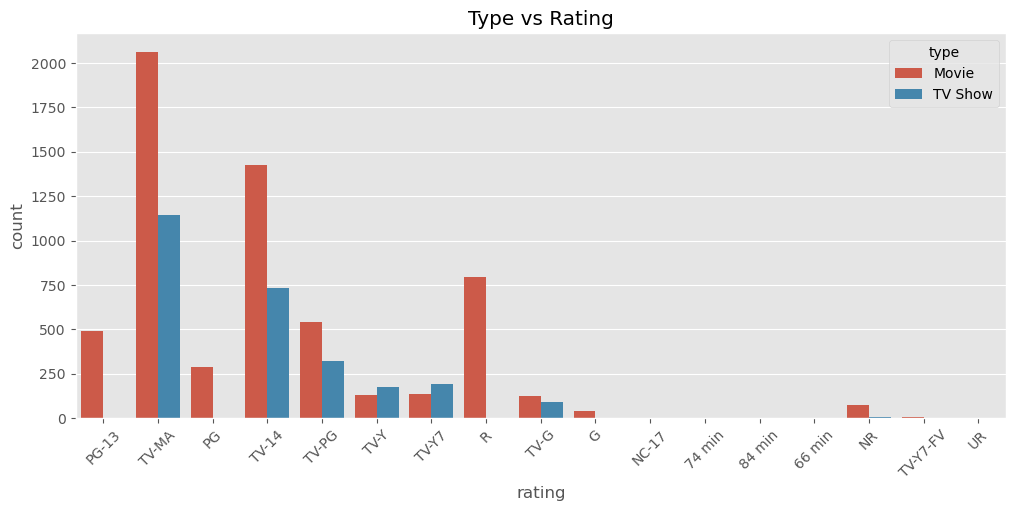

In [89]:
plt.figure(figsize=(12,5))
sns.countplot(x = 'rating',hue='type',data = df)
plt.xticks(rotation=45)
plt.title("Type vs Rating")
plt.show()

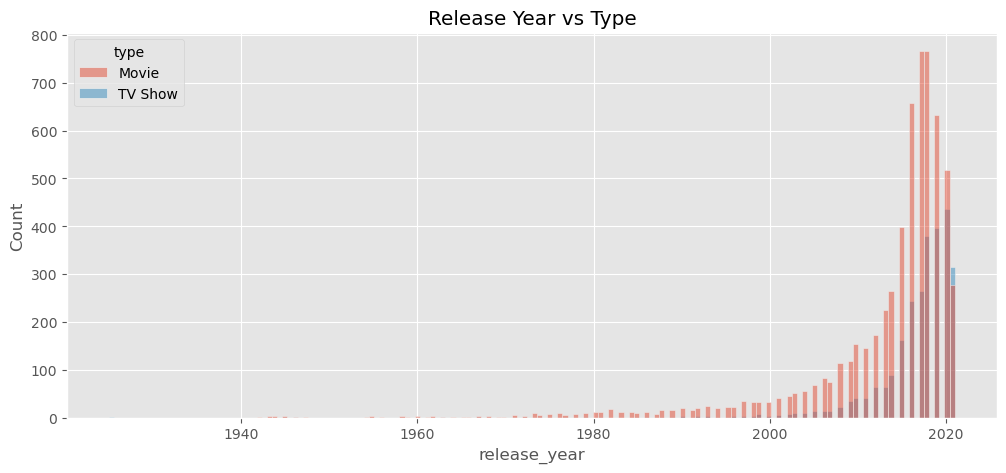

In [90]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='release_year', hue='type')
plt.title("Release Year vs Type")
plt.show()

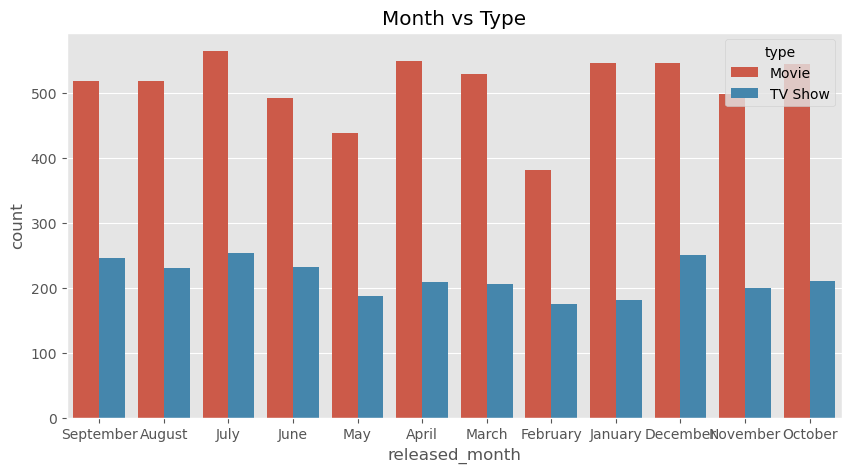

In [91]:
plt.figure(figsize=(10,5))
sns.countplot(x='released_month', hue='type', data=df)
plt.title("Month vs Type")
plt.show()

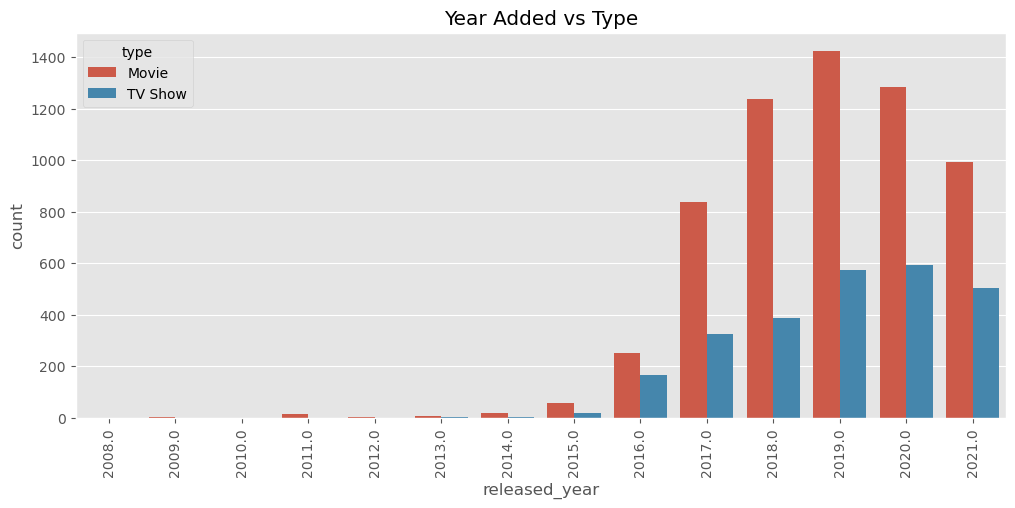

In [92]:
plt.figure(figsize=(12,5))
sns.countplot(x='released_year', hue='type', data=df)
plt.xticks(rotation=90)
plt.title("Year Added vs Type")
plt.show()

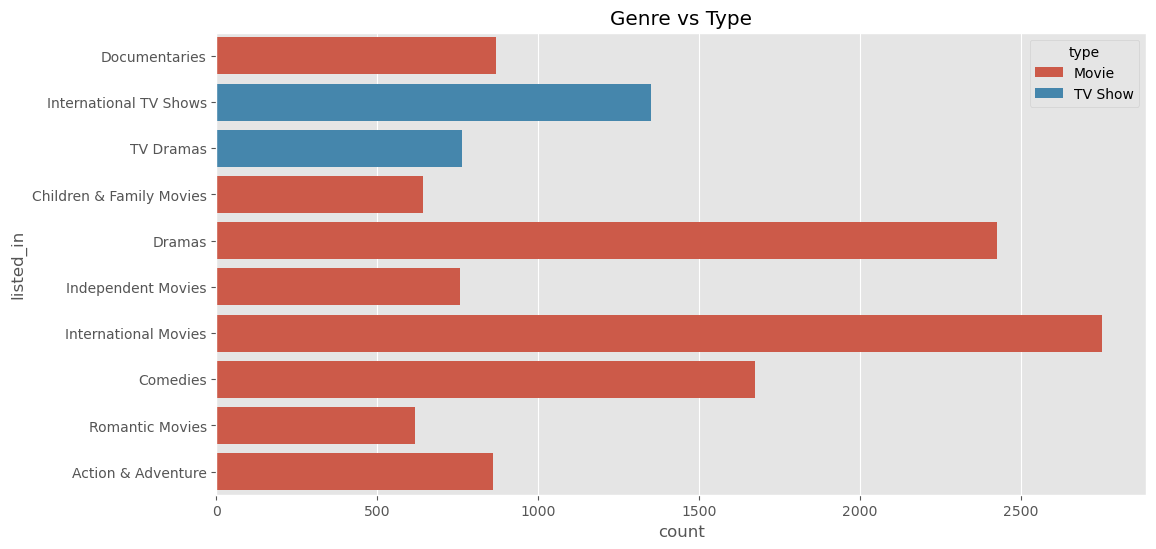

In [94]:
genre = df.copy()
genre['listed_in'] = genre['listed_in'].str.split(', ')
genre = genre.explode('listed_in')
top = genre['listed_in'].value_counts().head(10).index
genre = genre[genre['listed_in'].isin(top)]
plt.figure(figsize=(12,6))
sns.countplot(y='listed_in', hue='type', data=genre)
plt.title("Genre vs Type")
plt.show()

**1.Pie Chart - Movies vs TV Shows**

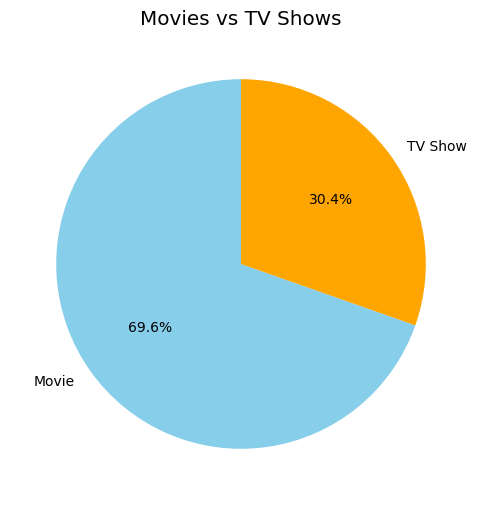

In [95]:
plt.figure(figsize=(6,6))
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','orange'],
    startangle=90)
plt.title("Movies vs TV Shows")
plt.ylabel("")
plt.show()

**Observation**

 Movies account for **69.6%** of the total Netflix content.
 TV Shows account for **30.4%** of the content.

 This shows that Netflix has a larger collection of movies than TV shows.


**2.Top 15 Directors**

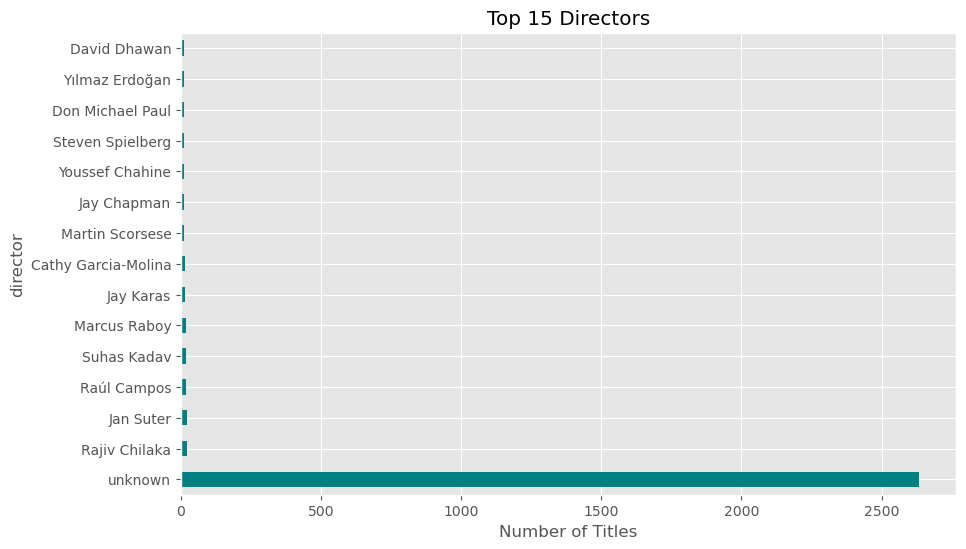

In [96]:
director = df['director'].dropna().str.split(', ').explode()
top_directors = director.value_counts().head(15)
plt.figure(figsize=(10,6))
top_directors.plot(
    kind='barh',
    color='teal')
plt.title("Top 15 Directors")
plt.xlabel("Number of Titles")
plt.show()

**Observation**

Most titles in the dataset have the director listed as **"Unknown"**.
This indicates that director information is missing for a large number of Netflix titles.

The large number of missing director names suggests incomplete metadata in the dataset. 
Improving data quality by filling in missing director information can enhance content search, recommendations, and analysis.

**3. Top 15 Actors**

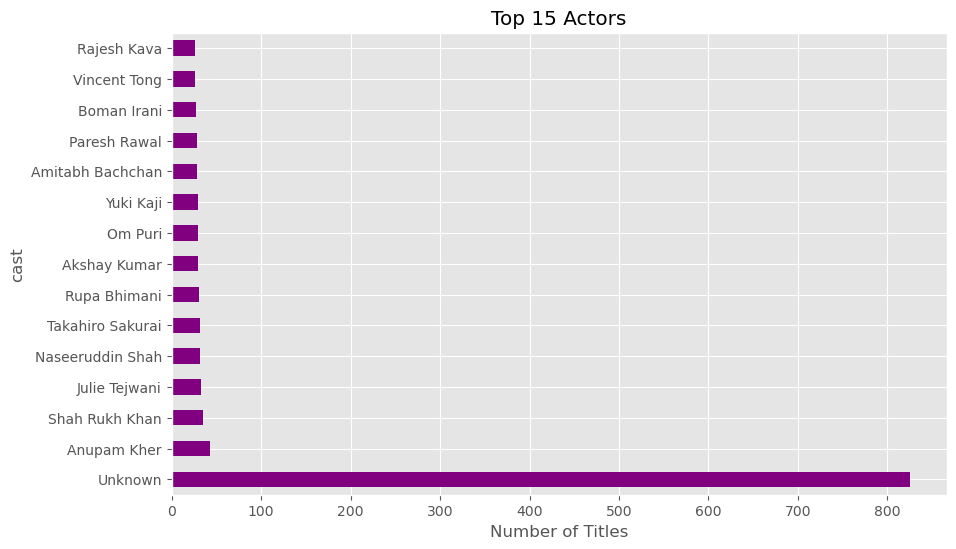

In [97]:
actors = df['cast'].dropna().str.split(', ').explode()
top_actors = actors.value_counts().head(15)
plt.figure(figsize=(10,6))
top_actors.plot(
    kind='barh',
    color='purple')
plt.title("Top 15 Actors")
plt.xlabel("Number of Titles")
plt.show()

**Observation**

The **"Unknown"** category has the highest number of titles, indicating that cast information is missing for many Netflix entries.

Now we are performing analysis by removing **Unknown** actors to get remaining actors  

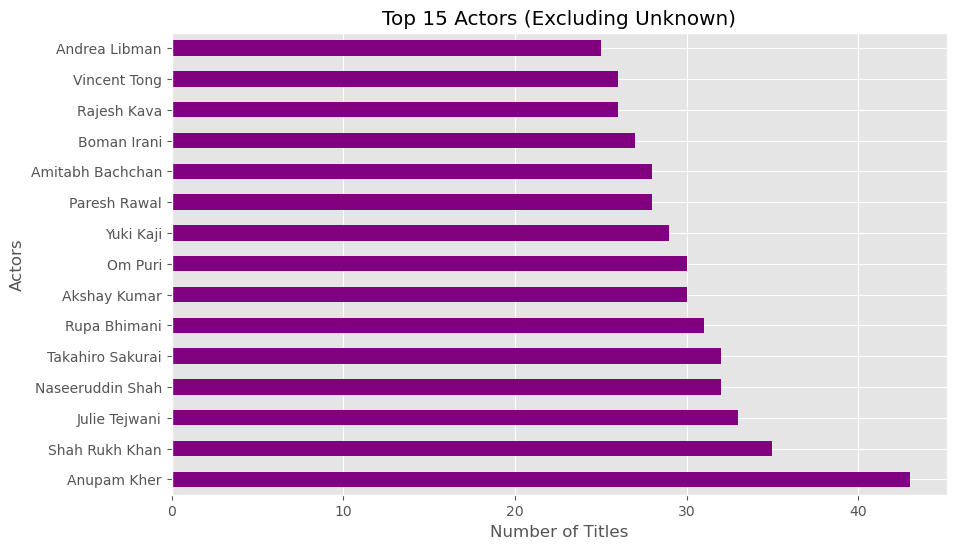

In [98]:
# Split the cast column into individual actors
actors = df['cast'].dropna().str.split(', ').explode()
# Remove "Unknown" entries (if present)
actors = actors[actors != "Unknown"]
top_actors = actors.value_counts().head(15)
plt.figure(figsize=(10,6))
top_actors.plot(
    kind='barh',
    color='purple')
plt.title("Top 15 Actors (Excluding Unknown)")
plt.xlabel("Number of Titles")
plt.ylabel("Actors")
plt.show()

**Observation**

**Anupam** Kher has the highest number of appearances in the Netflix dataset.

**Shah Rukh Khan**, **Julie Tejwani**, **Naseeruddin Shah**

**Takahiro Sakurai** are also among the most frequently featured actors.

 Most of the top actors appear in **25–45 titles**, indicating that no single actor dominates the Netflix catalog.


**4. Top 10 Genres**

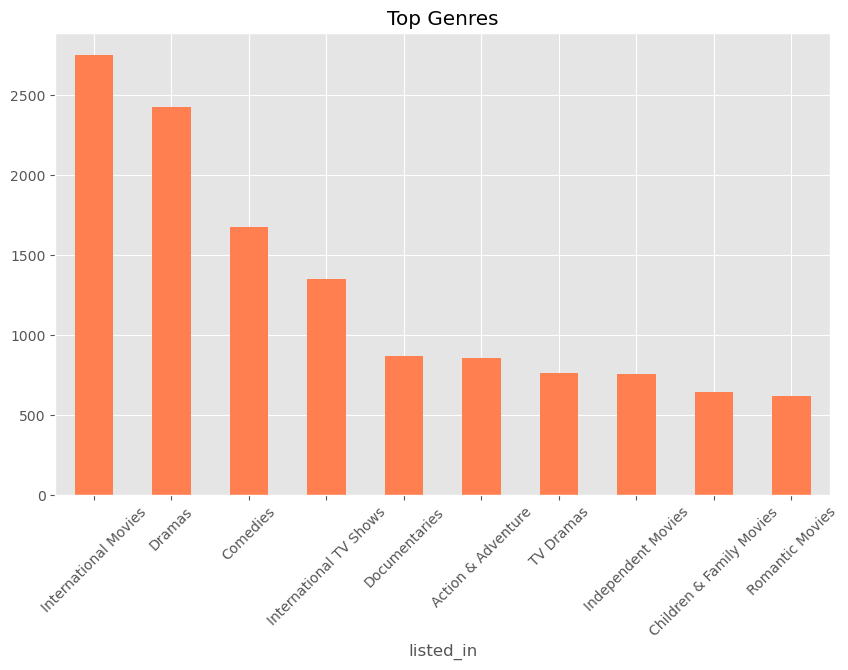

In [99]:
genres = df['listed_in'].str.split(', ').explode()
plt.figure(figsize=(10,6))
genres.value_counts().head(10).plot(
    kind='bar',
    color='coral')
plt.title("Top Genres")
plt.xticks(rotation=45)
plt.show()

**Observation**

 **International Movies** is the most frequent genre.
 
 **Dramas** and **Comedies** are the next most common genres.
 
 International TV Shows also contribute significantly to the catalog.


**5. Top 10 Countries**

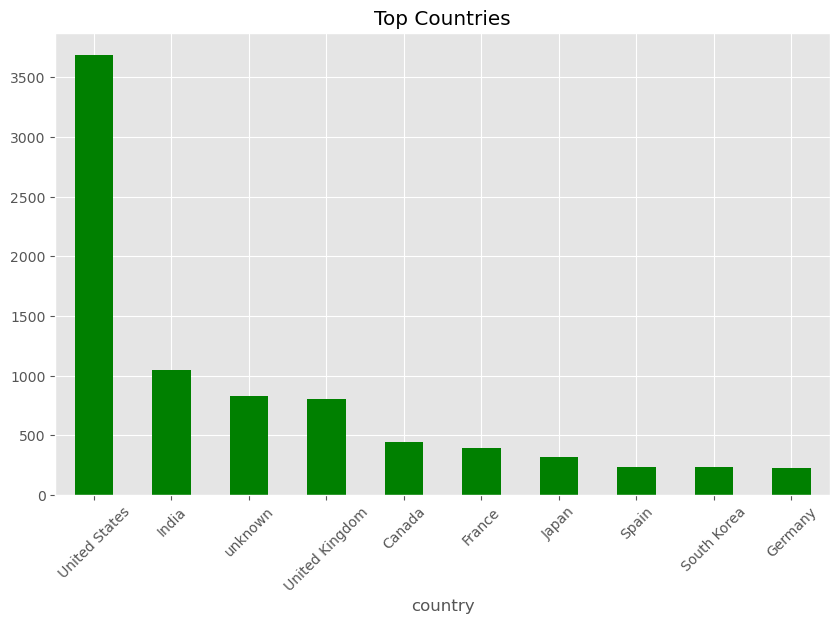

In [100]:
countries = df['country'].dropna().str.split(', ').explode()
plt.figure(figsize=(10,6))
countries.value_counts().head(10).plot(
    kind='bar',
    color='green')
plt.title("Top Countries")
plt.xticks(rotation=45)
plt.show()

**Observation**

- **United States** has the highest number of Netflix titles.
- **India** is the second-largest contributor.
- Some titles have missing country information (**Unknown**).


**6. Monthly Content Added**

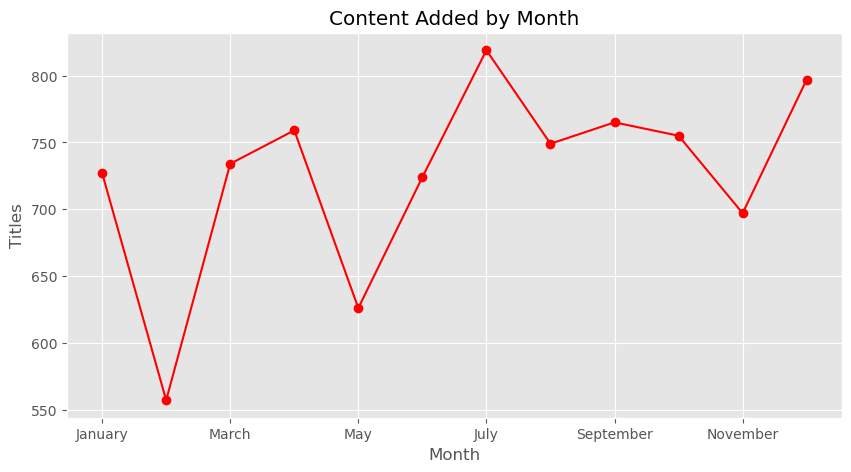

In [103]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December']

monthly_content = (
    df['date_added']
    .dropna()
    .dt.month_name()
    .value_counts()
    .reindex(month_order))

plt.figure(figsize=(10,5))
monthly_content.plot(
    kind='line',
    marker='o',
    color='red')

plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Titles")
plt.grid(True)
plt.show()

**Observation**

- **July** has the highest number of content additions.
- **February** has the lowest number of content additions.
- Content additions remain relatively consistent throughout the year.

**7. Netflix Growth Over Years**

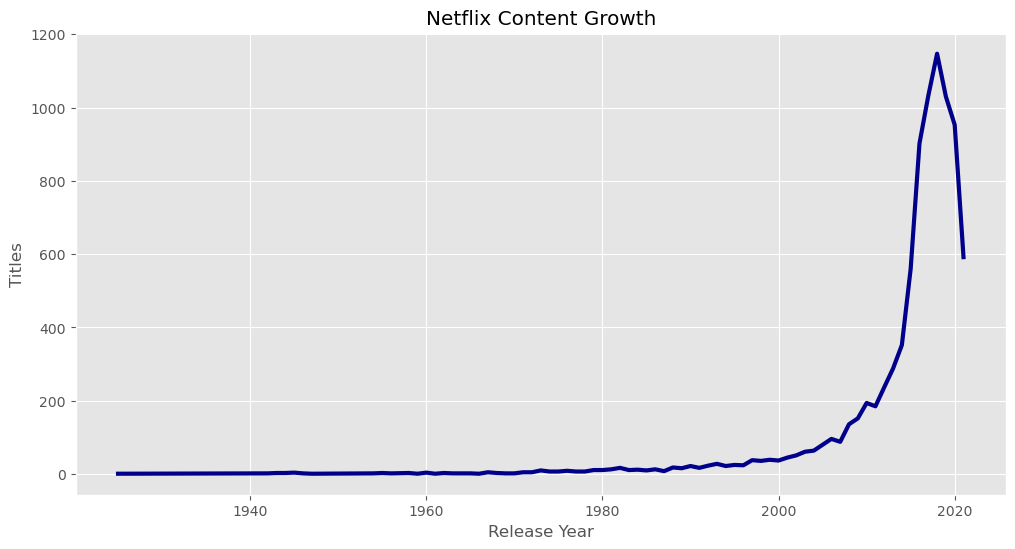

In [104]:
year = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
year.plot(
    color='darkblue',
    linewidth=3)
plt.title("Netflix Content Growth")
plt.xlabel("Release Year")
plt.ylabel("Titles")
plt.show()

**Observation**

The number of titles released on Netflix increased gradually until the early 2000s.
- Content growth accelerated significantly after **2015**.
- **2019** recorded the highest number of titles in the dataset.
- After 2019, the number of releases declined slightly in 2020 and 2021.


**8. Movie Duration Box Plot**

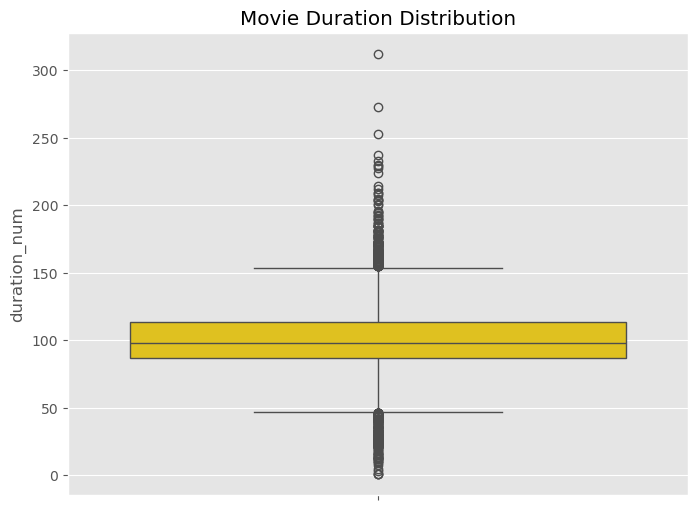

In [106]:
movies = df[df['type']=='Movie'].copy()
movies['duration_num'] = movies['duration'].str.extract('(\d+)').astype(int)
plt.figure(figsize=(8,6))
sns.boxplot(y=movies['duration_num'], color='gold')
plt.title("Movie Duration Distribution")
plt.show()

**Observation**
- The median movie duration is approximately **95–100 minutes**.
- Most movies have a duration between **85 and 110 minutes**, as shown by the box.
- Several movies have much shorter or much longer durations, which appear as **outliers**.
- A few movies exceed **200 minutes**, while some are less than **50 minutes** long.


**9. Top 10 Years with Most Releases**

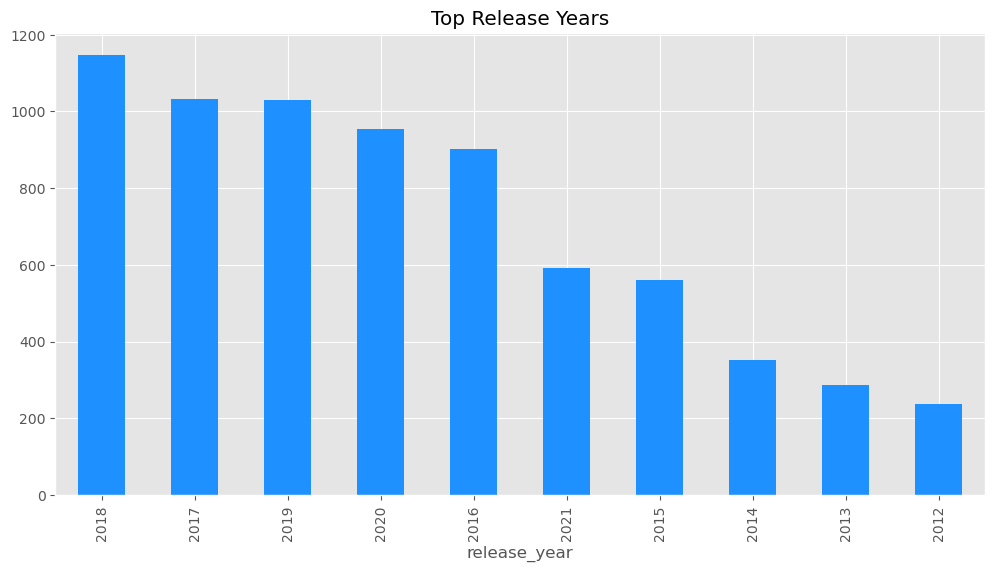

In [107]:
plt.figure(figsize=(12,6))
df['release_year'].value_counts().head(10).plot(
    kind='bar',
    color='dodgerblue')
plt.title("Top Release Years")
plt.show()

**Observation**
- **2018** has the highest number of titles in the Netflix dataset.
- **2017** and **2019** also have a large number of releases, showing a period of rapid content growth.
- The number of titles decreases after **2020**.
- Older release years have fewer titles compared to recent years

**10. Movie vs TV Show by Rating**

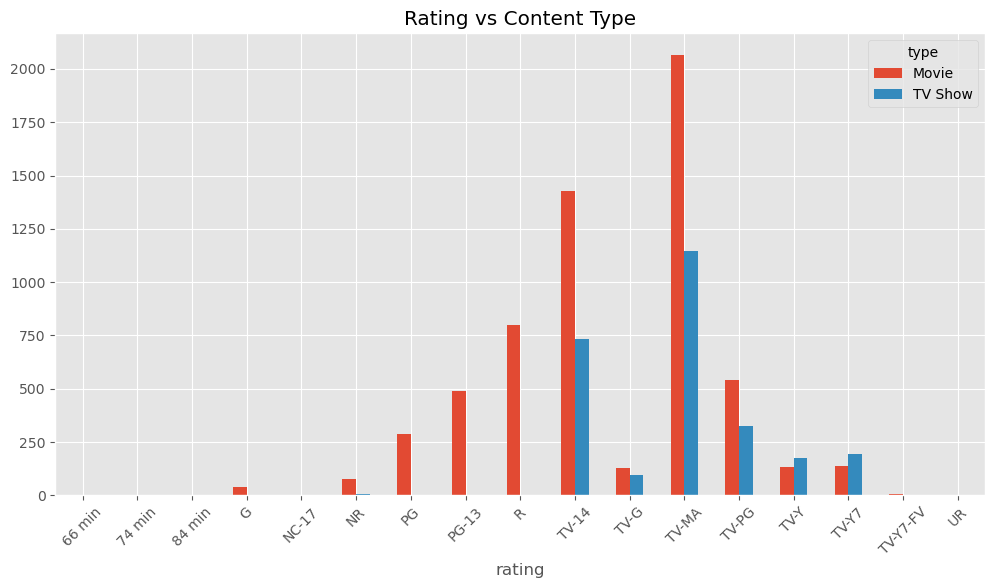

In [109]:
pivot = pd.crosstab(df['rating'], df['type'])
pivot.plot(
    kind='bar',
    figsize=(12,6))
plt.title("Rating vs Content Type")
plt.xticks(rotation=45)
plt.show()

**Observation**

- **TV-MA** is the most common rating for both Movies and TV Shows.
- Movies have more **R** and **PG-13** rated titles.
- TV Shows include more **TV-Y**, **TV-Y7**, and **TV-G** content.

**11. Donut Chart**

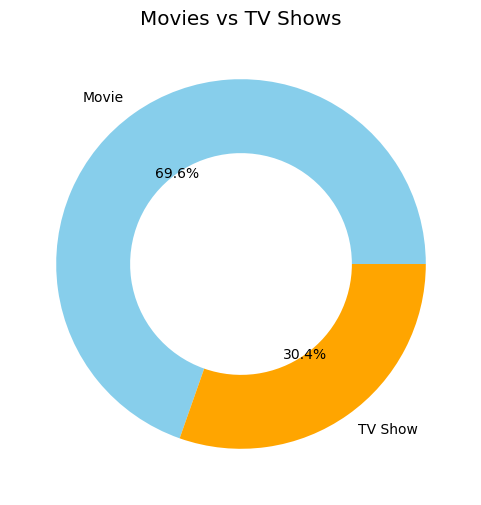

In [111]:
plt.figure(figsize=(6,6))
plt.pie(
    df['type'].value_counts(),
    labels=df['type'].value_counts().index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4},
    colors=['skyblue','orange'])
plt.title("Movies vs TV Shows")
plt.show()

**12. Area Chart**

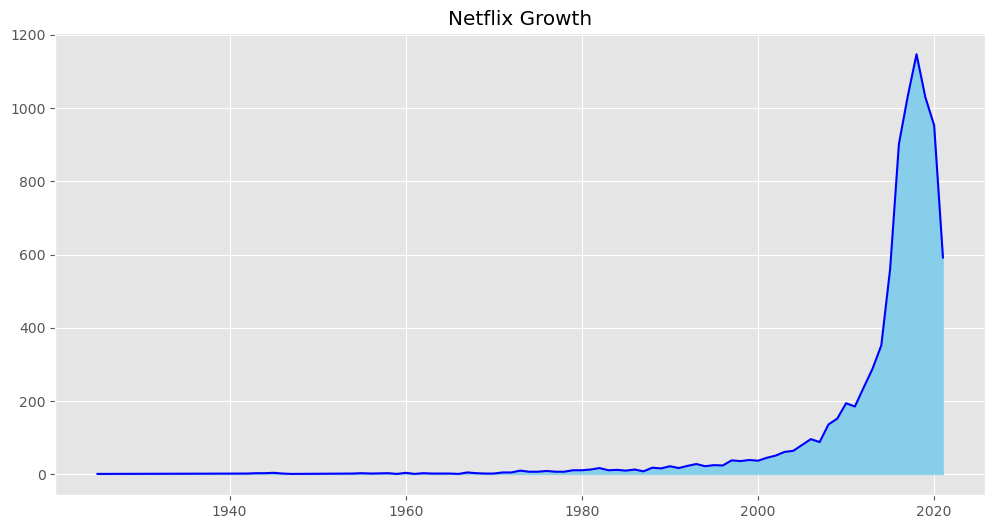

In [112]:
year = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.fill_between(
    year.index,
    year.values,
    color='skyblue')
plt.plot(year.index, year.values, color='blue')
plt.title("Netflix Growth")
plt.show()

**13. Lollipop Chart**

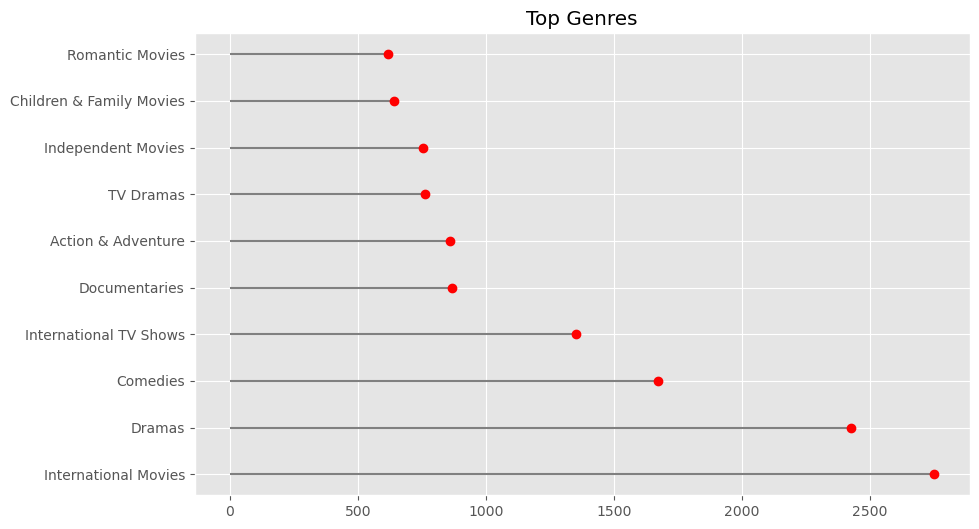

In [113]:
top = genres.value_counts().head(10)
plt.figure(figsize=(10,6))
plt.hlines(
    y=top.index,
    xmin=0,
    xmax=top.values,
    color='gray')
plt.plot(
    top.values,
    top.index,
    "o",
    color="red")
plt.title("Top Genres")
plt.show()

**14. Cumulative Growth**

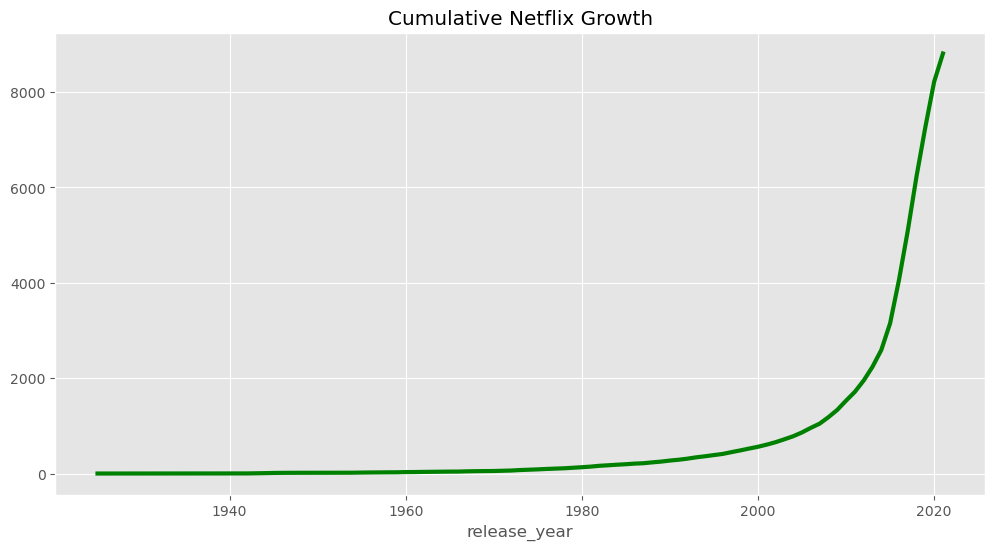

In [114]:
growth = df['release_year'].value_counts().sort_index().cumsum()
plt.figure(figsize=(12,6))
growth.plot(
    color='green',
    linewidth=3)
plt.title("Cumulative Netflix Growth")
plt.show()